In [ ]:
# Import necessary libraries for exploratory data analysis (EDA) and plotting
import numpy as np  # Shortened to np
import pandas as pd  # Shortened to pd
import matplotlib.pyplot as plt
import seaborn as sns  # Shortened to snsf

# Ensure plots appear in the notebook
%matplotlib inline

## Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

## Model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
# Note: In Scikit-Learn 1.2+, "plot_roc_curve" was changed to "RocCurveDisplay"
from sklearn.metrics import RocCurveDisplay

# Print last updated timestamp
import time
print(f"Last updated: {time.asctime()}")

ibm_analytics =pd.read_csv(r'WA_Fn-UseC_-HR-Employee-Attrition.csv')

Last updated: Sun Feb 22 12:15:37 2026


In [ ]:
ibm_analytics.shape

(1470, 35)

In [ ]:
ibm_analytics.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
summary =ibm_analytics.describe()
round(summary,2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [ ]:
ibm_analytics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
ibm_analytics.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<Axes: xlabel='Attrition'>

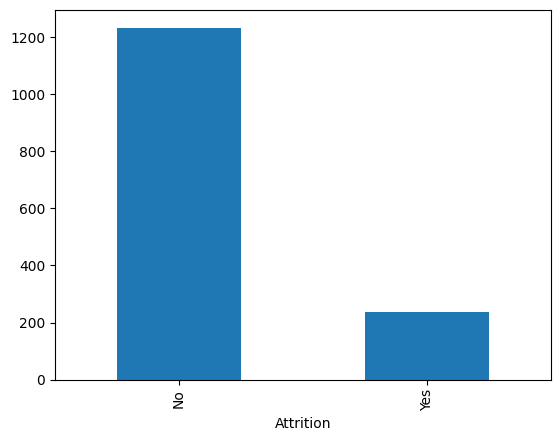

In [ ]:
ibm_analytics.Attrition.value_counts().plot(kind='bar')

<Axes: xlabel='Attrition'>

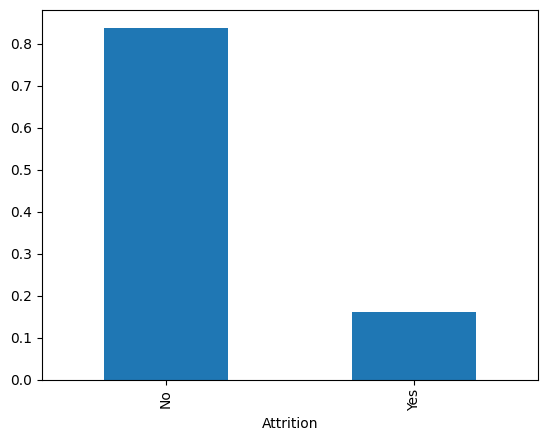

In [ ]:
# normalized value counts
ibm_analytics.Attrition.value_counts(normalize=True).plot(kind='bar')

Gender
Male      882
Female    588
Name: count, dtype: int64

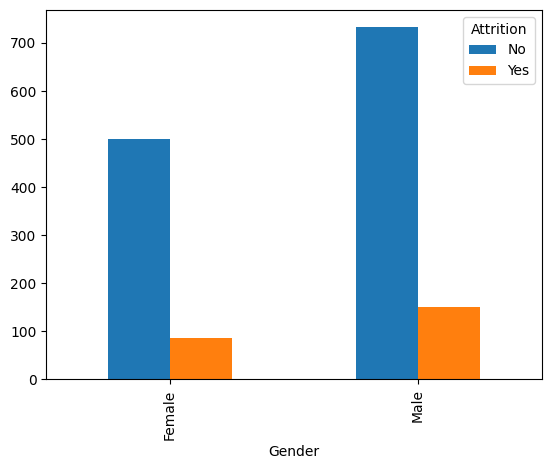

In [ ]:
# gender vs attrition
pd.crosstab(ibm_analytics.Gender, ibm_analytics.Attrition).plot(kind='bar')


In [ ]:
ibm_analytics.Gender.value_counts()
pd.crosstab( ibm_analytics.Attrition,ibm_analytics.Gender)

# In general more males have more attrition rates than females 17% vs 14.7%

Gender,Female,Male
Attrition,,
No,501,732
Yes,87,150


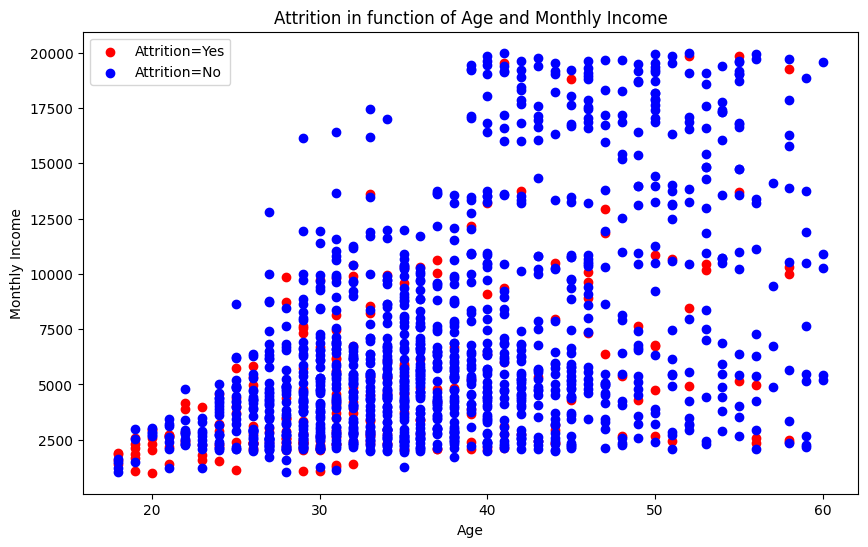

In [6]:
# Age vs attrition scatterplot

plt.figure(figsize=(10,6))

plt.scatter(  ibm_analytics.Age[ibm_analytics.Attrition=='Yes'],
            ibm_analytics.MonthlyIncome[ibm_analytics.Attrition=='Yes'],
            color='red', label='Attrition=Yes')

plt.scatter(  ibm_analytics.Age[ibm_analytics.Attrition=='No'],
            ibm_analytics.MonthlyIncome[ibm_analytics.Attrition=='No'],
            color='blue', label='Attrition=No')

# Add some helpful info
plt.title("Attrition in function of Age and Monthly Income")
plt.xlabel("Age")
plt.legend(["Attrition=Yes", "Attrition=No"])
plt.ylabel("Monthly Income");

<Axes: >

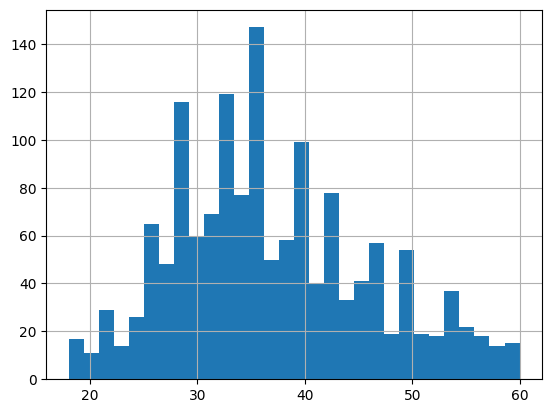

In [19]:
#age distribution

ibm_analytics.Age.hist(bins=30)

In [10]:
# correlation between independent variables

# select numeric columns only to avoid conversion errors
numeric_df = ibm_analytics.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
corr_matrix

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


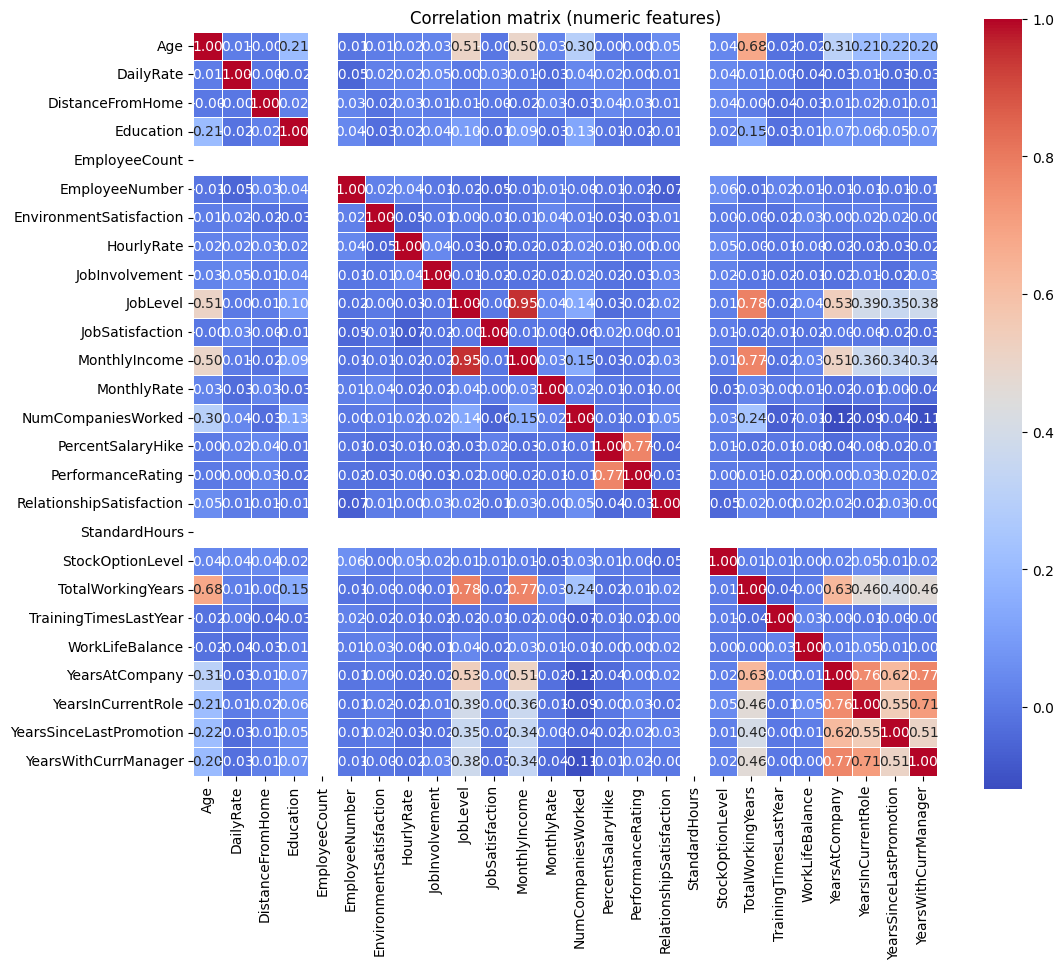

In [12]:
# correlation heatmap for numeric features
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation matrix (numeric features)')
plt.show()

In [37]:
X = ibm_analytics.drop('Attrition', axis=1)
y = ibm_analytics.Attrition

# Encode categorical columns in X
from sklearn.preprocessing import LabelEncoder
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object', 'category']).columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

X = X_encoded
X.head()

y.head()

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object

In [38]:
np.random.seed(32)

X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.2);

len(X_Train), len(X_Test), len(y_Train), len(y_Test)

(1176, 294, 1176, 294)

In [30]:
X_Train.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1012,31,Travel_Frequently,667,Sales,1,4,Life Sciences,1,1427,2,...,2,80,0,1,3,3,1,0,0,0
348,42,Travel_Rarely,810,Research & Development,23,5,Life Sciences,1,468,1,...,2,80,0,16,2,3,1,0,0,0
672,42,Travel_Rarely,462,Sales,14,2,Medical,1,936,3,...,1,80,0,10,6,3,5,4,0,3
372,35,Travel_Rarely,755,Research & Development,9,4,Life Sciences,1,496,3,...,3,80,0,10,5,3,1,1,0,0
611,35,Travel_Rarely,950,Research & Development,7,3,Other,1,845,3,...,2,80,0,17,3,4,8,5,1,6


In [40]:
models = {"KNN": KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(), 
          "Random Forest": RandomForestClassifier(),
          "Decision Trees": DecisionTreeClassifier()}

def fit_and_score(models, X_Train, y_Train, X_Test, y_Test):
    """
    Fits and evaluates given machine learning models.
    
    models: a dict of different Scikit-Learn machine learning models
    X_Train: training data (features)
    y_Train: training data (labels)
    X_Test: test data (features)
    y_Test: test data (labels)
    
    Returns a dictionary of model names and their corresponding accuracy scores.
    """
    np.random.seed(32)
    model_scores = {}
    
    for name, model in models.items():
        # Fit the model to the training data
        model.fit(X_Train, y_Train)
        # Evaluate the model on the test data
        score = model.score(X_Test, y_Test)
        # Store the score in the dictionary
        model_scores[name] = score
        
    return model_scores

NameError: name 'DecisionTreeClassifier' is not defined

In [39]:
model_scores = fit_and_score(models=models, X_Train=X_Train, y_Train=y_Train, X_Test=X_Test, y_Test=y_Test)

model_scores

c:\Users\Admin pc\machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.8129251700680272,
 'Logistic Regression': 0.8163265306122449,
 'Random Forest': 0.8503401360544217}